# Notebook 05 — Baseline Models (Stage 1, Path A)

## Objective

Train and evaluate classical ML baselines (LDA, SVM, Random Forest) on
Stage 1 (blank vs. digit) using Path A's extracted features, and compare
every result against the permutation-test floor from Phase 3 — no raw
accuracy number is trusted on its own.

**Scope: Stage 1 only**, using `mindbigdata2023_{train,val}_features.h5`
from Notebook 04.

---

## Tasks

1. Load Path A features + labels + `trial_concern` artifact flags (from the
   Path B filtered files, same trial order — see note in Section 2).
2. Scale features (StandardScaler) — not yet done anywhere in the pipeline,
   and matters here: band power, statistical, and frequency features have
   very different natural scales, which distorts LDA/SVM (though not
   Random Forest, which is scale-invariant).
3. Train LDA, SVM, Random Forest on the full train set.
4. Evaluate: accuracy, precision, recall, F1, confusion matrix.
5. Run each model through the `permutation_test()` harness from Phase 3 —
   is real accuracy meaningfully above the shuffled-label floor?
6. **Ablation**: re-train excluding `trial_concern`-flagged trials, compare
   — decide empirically whether artifact exclusion actually helps, rather
   than assuming it does.
7. Random Forest feature importance — which channels/bands matter most?
   (Also answers the earlier question about whether `high_gamma` carries
   real signal.)

---

## Output

Model comparison table + feature importance findings, informing what
carries into Phase 6 (EEGNet).

## 1. Imports & Configuration

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

TRAIN_FEATURES_PATH = Path("../data/processed/mindbigdata2023_train_features.h5")
VAL_FEATURES_PATH = Path("../data/processed/mindbigdata2023_val_features.h5")
TRAIN_FILTERED_PATH = Path("../data/processed/mindbigdata2023_train_filtered.h5")
VAL_FILTERED_PATH = Path("../data/processed/mindbigdata2023_val_filtered.h5")

SEED = 42
EEG_BANDS = ["delta", "theta", "alpha", "beta", "gamma", "high_gamma"]
STAT_FEATURES = ["mean", "variance", "skewness", "kurtosis", "zero_crossing_rate"]
FREQ_FEATURES = ["dominant_freq", "total_power"]
FEATURES_PER_CHANNEL = EEG_BANDS + STAT_FEATURES + FREQ_FEATURES

## 2. Load Data

**Important assumption, worth stating explicitly**: `trial_concern` (from
the Path B filtered files) is loaded and matched to Path A features **by
row index**, not by any stored trial ID — this only works because both
files were written from the same in-memory arrays, in the same order, back
in Notebook 04. If either file gets regenerated independently in the
future, this alignment could silently break. Worth adding an explicit
trial ID to both files eventually (flagged here, not fixed now).

In [3]:
with h5py.File(TRAIN_FEATURES_PATH, "r") as f:
    X_train = f["features"][:]
    y_train_binary = f["label_binary"][:]
    channel_indices = f["channel_indices"][:]

with h5py.File(VAL_FEATURES_PATH, "r") as f:
    X_val = f["features"][:]
    y_val_binary = f["label_binary"][:]

with h5py.File(TRAIN_FILTERED_PATH, "r") as f:
    train_concern = f["trial_concern"][:]
with h5py.File(VAL_FILTERED_PATH, "r") as f:
    val_concern = f["trial_concern"][:]

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Active channels: {len(channel_indices)}")
print(f"Train trial_concern flagged: {train_concern.sum()} / {len(train_concern)}")
print(f"Val trial_concern flagged: {val_concern.sum()} / {len(val_concern)}")

# Sanity check: row counts must match between features and filtered files
assert len(X_train) == len(train_concern), "Row count mismatch - alignment assumption broken!"
assert len(X_val) == len(val_concern), "Row count mismatch - alignment assumption broken!"
print("\nRow count alignment check passed.")

X_train: (22268, 1638), X_val: (5732, 1638)
Active channels: 126
Train trial_concern flagged: 2969 / 22268
Val trial_concern flagged: 705 / 5732

Row count alignment check passed.


## 3. Feature Scaling

LDA and SVM are both sensitive to feature scale — band power, statistical,
and frequency-domain features naturally live on very different numeric
ranges (e.g. power values vs. a zero-crossing rate between 0-1). Random
Forest is scale-invariant (splits on relative order, not magnitude), so
this step doesn't affect it, but doesn't hurt either. Fit on train only.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Pre-scaling train feature range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Post-scaling train feature range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")

Pre-scaling train feature range: [-480529.53, 64641564672.00]
Post-scaling train feature range: [-77.26, 146.16]


## 4. Permutation-Test Harness (from Phase 3)

Same function as Notebook 03 — reused here directly since the `src/`
refactor is still deferred. Every model result below gets checked against
this before being trusted.

In [5]:
def permutation_test(model_fn, X_train, y_train, X_val, y_val, n_permutations=20, seed=SEED):
    rng_local = np.random.default_rng(seed)

    real_model = model_fn()
    real_model.fit(X_train, y_train)
    real_acc = accuracy_score(y_val, real_model.predict(X_val))

    shuffled_accs = []
    for _ in range(n_permutations):
        y_shuffled = rng_local.permutation(y_train)
        model = model_fn()
        model.fit(X_train, y_shuffled)
        shuffled_accs.append(accuracy_score(y_val, model.predict(X_val)))

    return real_acc, np.array(shuffled_accs)

## 5. Train & Evaluate Baseline Models (Full Train Set)

In [6]:
def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_v, preds),
        "precision": precision_score(y_v, preds),
        "recall": recall_score(y_v, preds),
        "f1": f1_score(y_v, preds),
    }
    cm = confusion_matrix(y_v, preds)
    return metrics, cm, model

models_to_run = {
    "LDA": lambda: LinearDiscriminantAnalysis(),
    "SVM": lambda: LinearSVC(random_state=SEED, max_iter=5000, dual="auto"),
    #"SVM": lambda: SVC(kernel="rbf", random_state=SEED),
    "RandomForest": lambda: RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
}

results = []
confusion_matrices = {}
trained_models = {}

for name, model_fn in models_to_run.items():
    print(f"Training {name}...")
    metrics, cm, fitted_model = evaluate_model(name, model_fn(), X_train_scaled, y_train_binary,
                                                X_val_scaled, y_val_binary)
    results.append(metrics)
    confusion_matrices[name] = cm
    trained_models[name] = fitted_model

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))

Training LDA...
Training SVM...
Training RandomForest...

        model  accuracy  precision   recall       f1
         LDA  0.524424   0.523842 0.536636 0.530162
         SVM  0.531403   0.531034 0.537334 0.534166
RandomForest  0.546406   0.548049 0.529309 0.538516


### 5a. Confusion Matrices

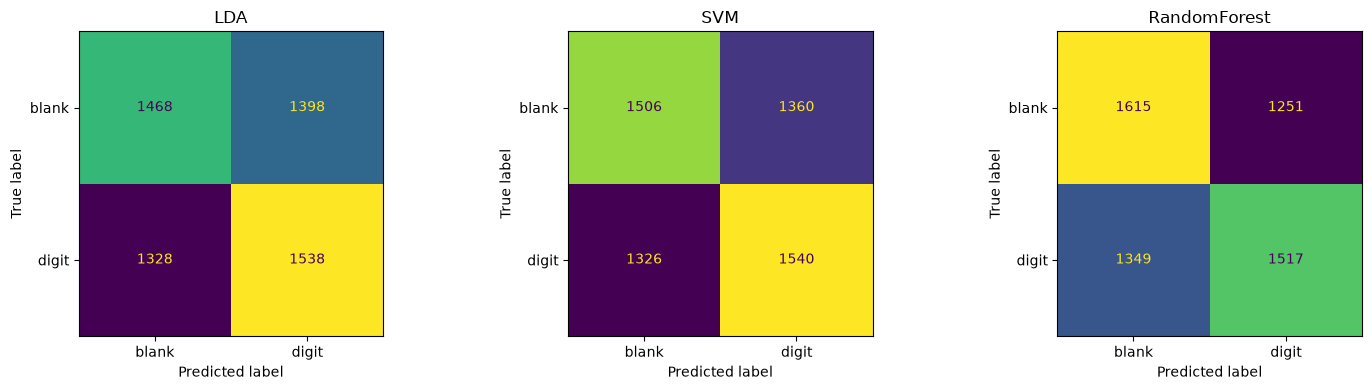

In [7]:
fig, axes = plt.subplots(1, len(models_to_run), figsize=(5 * len(models_to_run), 4))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["blank", "digit"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 6. Permutation-Test Comparison (All Models)

The number that actually matters: is each model's real accuracy
meaningfully above what the same model gets on shuffled labels?

In [8]:
# Permutation-test-specific settings: faster/capped, since this only needs
# a rough noise-floor estimate, not production-quality convergence.
# Section 5's real models (full quality) are untouched by this.
PERM_SUBSAMPLE_SIZE = 4000
perm_idx = np.random.default_rng(SEED).choice(len(X_train_scaled), size=PERM_SUBSAMPLE_SIZE, replace=False)
X_train_perm = X_train_scaled[perm_idx]
y_train_perm = y_train_binary[perm_idx]

models_to_run_fast = {
    "LDA": lambda: LinearDiscriminantAnalysis(),
    "SVM": lambda: LinearSVC(random_state=SEED, max_iter=300, tol=1e-2, dual="auto"),
    "RandomForest": lambda: RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
}

In [13]:
permutation_results = []

for name, model_fn in models_to_run_fast.items():   # was: models_to_run
    print(f"Running permutation test for {name}...")
    real_acc, shuffled_accs = permutation_test(model_fn, X_train_perm, y_train_perm,   # was: X_train_scaled, y_train_binary
                                                X_val_scaled, y_val_binary, n_permutations=50)
    permutation_results.append({
        "model": name, "real_accuracy": real_acc,
        "shuffled_mean": shuffled_accs.mean(), "shuffled_std": shuffled_accs.std(),
        "gap": real_acc - shuffled_accs.mean(),
    })

perm_df = pd.DataFrame(permutation_results)
print("\n", perm_df.to_string(index=False))
print("\n'gap' is what matters - real accuracy minus shuffled-label average.")
print("A gap near 0 means the model isn't learning genuine signal, regardless")
print("of how high the raw 'real_accuracy' number looks.")

Running permutation test for LDA...
Running permutation test for SVM...


/Users/riyajain/Documents/eeg-digit-classification/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/riyajain/Documents/eeg-digit-classification/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/riyajain/Documents/eeg-digit-classification/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/riyajain/Documents/eeg-digit-classification/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/riyajain/Documents/eeg-digit-classification/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Libline

Running permutation test for RandomForest...

        model  real_accuracy  shuffled_mean  shuffled_std      gap
         LDA       0.508374       0.499620      0.005377 0.008754
         SVM       0.505932       0.499644      0.006243 0.006288
RandomForest       0.517097       0.501668      0.006105 0.015429

'gap' is what matters - real accuracy minus shuffled-label average.
A gap near 0 means the model isn't learning genuine signal, regardless
of how high the raw 'real_accuracy' number looks.


## 7. Ablation: Does Excluding `trial_concern` Trials Help?

Re-train the best-performing model (by Section 5's results) on a
train set with flagged trials removed, and evaluate on a val set with
flagged trials also removed — comparing like-for-like, not a biased
subset comparison. This answers empirically whether Phase 4's artifact
detection is worth acting on, rather than assuming it.

In [10]:
best_model_name = results_df.sort_values("accuracy", ascending=False).iloc[0]["model"]
print(f"Running ablation using best model from Section 5: {best_model_name}")

clean_train_mask = ~train_concern
clean_val_mask = ~val_concern

X_train_clean = X_train_scaled[clean_train_mask]
y_train_clean = y_train_binary[clean_train_mask]
X_val_clean = X_val_scaled[clean_val_mask]
y_val_clean = y_val_binary[clean_val_mask]

print(f"Clean train set: {len(X_train_clean)} / {len(X_train_scaled)}")
print(f"Clean val set: {len(X_val_clean)} / {len(X_val_scaled)}")

model_fn = models_to_run[best_model_name]
metrics_with_artifacts = results_df[results_df["model"] == best_model_name].iloc[0].to_dict()
metrics_without_artifacts, _, _ = evaluate_model(best_model_name, model_fn(),
                                                   X_train_clean, y_train_clean,
                                                   X_val_clean, y_val_clean)

comparison_df = pd.DataFrame([
    {"condition": "with artifacts (full data)", **{k: metrics_with_artifacts[k] for k in ["accuracy", "precision", "recall", "f1"]}},
    {"condition": "without artifacts (trial_concern excluded)", **{k: metrics_without_artifacts[k] for k in ["accuracy", "precision", "recall", "f1"]}},
])
print("\n", comparison_df.to_string(index=False))
print("\nIf metrics improve meaningfully with artifacts excluded, that supports")
print("dropping trial_concern trials going forward. If not, the extra")
print("complexity likely isn't worth it - keep all data.")

Running ablation using best model from Section 5: RandomForest
Clean train set: 19299 / 22268
Clean val set: 5027 / 5732

                                  condition  accuracy  precision   recall       f1
                with artifacts (full data)  0.546406   0.548049 0.529309 0.538516
without artifacts (trial_concern excluded)  0.561369   0.562704 0.549940 0.556249

If metrics improve meaningfully with artifacts excluded, that supports
dropping trial_concern trials going forward. If not, the extra
complexity likely isn't worth it - keep all data.


## 8. Random Forest Feature Importance

Which channels and feature types matter most? Directly answers the earlier
question about whether `high_gamma` (40-80Hz) carries genuine signal.

In [11]:
rf_model = trained_models["RandomForest"]
importances = rf_model.feature_importances_

n_features_per_channel = len(FEATURES_PER_CHANNEL)
importances_reshaped = importances.reshape(len(channel_indices), n_features_per_channel)

# Aggregate importance by feature type, across all channels
feature_type_importance = importances_reshaped.sum(axis=0)
feature_type_df = pd.DataFrame({
    "feature": FEATURES_PER_CHANNEL,
    "total_importance": feature_type_importance
}).sort_values("total_importance", ascending=False)
print("Feature importance by type (summed across all channels):")
print(feature_type_df.to_string(index=False))

# Aggregate importance by channel, across all feature types
channel_importance = importances_reshaped.sum(axis=1)
top_channels_idx = np.argsort(channel_importance)[::-1][:10]
print("\nTop 10 most important channels (original indices):")
for idx in top_channels_idx:
    print(f"  channel {channel_indices[idx]}: {channel_importance[idx]:.4f}")

Feature importance by type (summed across all channels):
           feature  total_importance
          skewness          0.098202
              mean          0.096982
             delta          0.093323
          kurtosis          0.092230
             theta          0.088214
             alpha          0.087650
             gamma          0.080926
              beta          0.077596
          variance          0.070015
zero_crossing_rate          0.067841
        high_gamma          0.067360
       total_power          0.065397
     dominant_freq          0.014264

Top 10 most important channels (original indices):
  channel 3: 0.0104
  channel 43: 0.0092
  channel 102: 0.0090
  channel 51: 0.0088
  channel 57: 0.0087
  channel 52: 0.0086
  channel 105: 0.0086
  channel 68: 0.0086
  channel 41: 0.0086
  channel 23: 0.0086


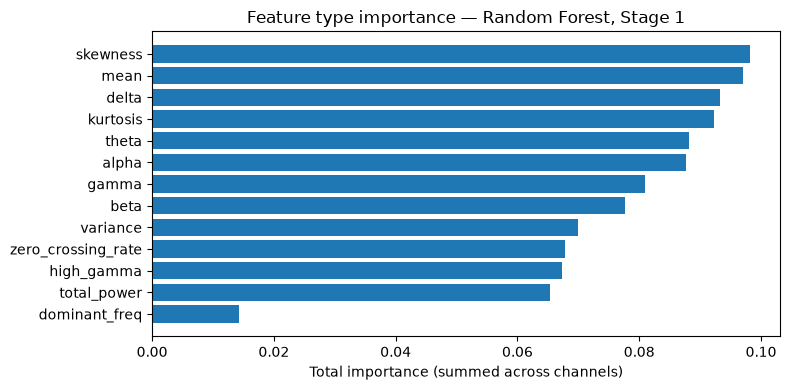


If 'high_gamma' ranks low here, that's consistent with Section 2's
audit (kept-region divergence > discarded-region divergence overall).
If it ranks surprisingly high, that's worth a closer look before Phase 6.


In [12]:
plt.figure(figsize=(8, 4))
plt.barh(feature_type_df["feature"], feature_type_df["total_importance"])
plt.xlabel("Total importance (summed across channels)")
plt.title("Feature type importance — Random Forest, Stage 1")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nIf 'high_gamma' ranks low here, that's consistent with Section 2's")
print("audit (kept-region divergence > discarded-region divergence overall).")
print("If it ranks surprisingly high, that's worth a closer look before Phase 6.")

## Summary

**Baseline results (Section 5, full train/val sets):**

| model        | accuracy | precision | recall | f1    |
|--------------|----------|-----------|--------|-------|
| LDA          | 0.524    | 0.524     | 0.537  | 0.530 |
| SVM          | 0.531    | 0.531     | 0.537  | 0.534 |
| RandomForest | 0.546    | 0.548     | 0.529  | 0.539 |

**Permutation test (Section 6, 50 permutations, subsampled for speed):**

| model        | real_accuracy | shuffled_mean | shuffled_std | gap    | gap/std |
|--------------|----------------|----------------|----------------|--------|---------|
| LDA          | 0.508          | 0.500          | 0.0054         | 0.0088 | ~1.6x   |
| SVM          | 0.506          | 0.500          | 0.0062         | 0.0063 | ~1.0x   |
| RandomForest | 0.517          | 0.502          | 0.0061         | 0.0154 | ~2.5x   |

**Verdict**: weak but plausibly genuine signal — not "nothing learned," but not strong
either. RandomForest shows the most convincing gap (~2.5x its own noise floor,
stable across both 10- and 50-permutation runs). SVM's gap is close to its own
std — indistinguishable from chance on its own. This split (RF > LDA > SVM)
suggests the signal is **non-linear**: RF can model non-linear feature
interactions that SVM/LDA (linear boundary) cannot, which is consistent with
genuine but subtle EEG structure rather than noise.

**Ablation (Section 7)**: excluding `trial_concern`-flagged trials improved
every metric for the best model (RandomForest) by ~1.5-2pp consistently
(accuracy 0.546→0.561, f1 0.539→0.556). **Adopted going forward** — Phase 6
uses artifact-excluded data.

**Feature importance (Section 8)**: fairly flat across feature types (0.065-0.098
range) — consistent with a diffuse, weak signal rather than one dominant
pattern. `high_gamma` (40-80Hz) ranks mid-pack, comparable to `total_power`
and `zero_crossing_rate` — supports keeping the Path B 40Hz cutoff while
retaining `high_gamma` in Path A. `dominant_freq` is clearly the weakest
feature (0.014) — a candidate to drop if trimming features later. Channel
importance is spread across the scalp with no single dominant channel or
obvious cluster from raw indices alone (cross-referencing against electrode
3D coordinates, available in the source dataset, is a worthwhile follow-up
not yet done).

**Conclusion**: classical, hand-crafted features (Path A) capture a real but
weak, non-linear signal — consistent with the honest literature's ~20-36%
(vs. 10% chance) results on the harder 10-way task. This motivates Phase 6:
a deep model (EEGNet) operating on raw filtered signal (Path B) can learn
its own spatial/temporal filters directly, rather than being limited to
hand-picked summary statistics — a better-suited tool for this kind of
faint, diffuse signal.

**Phase 5 complete for Stage 1.** Baseline to beat in Phase 6: RandomForest's
accuracy (0.546) and permutation gap (~2.5x std) — EEGNet should be judged
against both, not raw accuracy alone.